In [7]:
#Fresh dataset
import torch
import pandas as pd

def make_data(rows, cols): #makes dataframe of predictable data

  data = []
  for x in range (rows - 1):
    row = []
    for y in range (cols - 1):
      val = (x ** 2) + (3 * y) #can be any function -- for now, x^2 + 3y
      row.append(val)

    data.append(row)

  df = pd.DataFrame(data)
  return df

    0   1   2   3   4   5   6   7   8
0   0   3   6   9  12  15  18  21  24
1   1   4   7  10  13  16  19  22  25
2   4   7  10  13  16  19  22  25  28
3   9  12  15  18  21  24  27  30  33
4  16  19  22  25  28  31  34  37  40
5  25  28  31  34  37  40  43  46  49
6  36  39  42  45  48  51  54  57  60
7  49  52  55  58  61  64  67  70  73
8  64  67  70  73  76  79  82  85  88


In [9]:
#Simple train loop
import torch
import torch.nn as nn
import torch.optim as optim


def train(model, dataloader, num_epochs, lr, weight_decay):

  loss_fn = nn.CrossEntropyLoss() #(can change loss fn & optimizer if needed)
  optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

  #for early stopping:
  best_loss = float('inf')
  patience = 5
  counter = 0

  for epoch in range(num_epochs):
      print (f'EPOCH: {epoch}')

      running_loss = 0.0 #total loss over batches

      for inputs, targets in dataloader:

        #calculate loss by comparing predictions vs. targets:
        pred = model(inputs)
        loss = loss_fn(pred, targets)

        #backward pass/gradient descent:
        optimizer.zero_grad() #reset grads
        loss.backward() #calculate new grads
        optimizer.step() #update params

        running_loss += loss.item()

      if running_loss < best_loss:
        best_loss = running_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth') #save checkpoint of best model
      else:
        counter += 1
        if counter >= patience:
          print(f'Early stopping at epoch {epoch} because loss did not improve for {patience} epochs')
          return running_loss

  return running_loss


In [99]:
#CoLogs

def recurrence_formula(C: torch.Tensor, model_type):
  A_n, B_n = get_convergent_parts(C, model_type)
  return (A_n / B_n).item() #(makes it a float)

def get_convergent_parts(C: torch.Tensor, model_type):

  '''
  Compute A_n and B_n (convergents).

  A_0 = C_0
  A_1 = C_1 * C_0 + C_0
  A_n = (C_n * A_{n-1}) + A_{n-2}

  B_0 = 1
  B_1 = C_1
  B_n = (C_n * B_{n-1}) + C_{n-1}
  '''
  if not isinstance(C, torch.Tensor):
        C = torch.tensor(C, dtype=torch.float32)


  n = len(C)

  #CoFrNet
  if (model_type == 'CoFrNet'):
    #Base cases:
    if n == 1:
      A_1 = C[0]
      B_1 = 1.0
      return A_1, B_1

    if n == 2:
      A_2 = C[1] * C[0] + C[0]
      B_2 = C[1]
      return A_2, B_2

    A_prev = C[0]
    A_curr = C[1] * C[0] + C[0]
    B_curr = C[1]

    for i in range (2, n):
      A_next = C[i] * A_curr + A_prev
      B_next = C[i] * B_curr + 1
      A_prev, A_curr = A_curr, A_next
      B_curr = B_next

  else: #CoLogNet

    C = torch.pow(2, C) #raising 2^C

    #Base cases:
    if n == 1:
      return C[0], 1.0 #(A_0/B_0)

    if n == 2:
      return (C[1] * C[0] + C[0]), C[1]

    A_prev = C[0]
    A_curr = C[1] * C[0] + C[0]
    B_curr = C[1]

    for i in range(2, n):
      A_next = C[i] * A_curr + A_prev
      B_next = C[i] * B_curr + C[i - 1]
      A_prev, A_curr = A_curr, A_next
      B_curr = B_next

  return A_curr, B_curr

print(recurrence_formula(torch.tensor([1.0]), 'CoLogNet'))  # Should work!
print(recurrence_formula(torch.tensor([1.0, 0.0]), 'CoLogNet'))  # Should work!


2.0
4.0


[25.85571492818883, 55.221690960785494, 99.18127006401318, 33.879442259165415, 45.84387347828098, 97.3029092676644, 98.30004908037321, 43.43774897013727, 83.19323715552784, 60.705141019588304, 33.64851386516027, 93.10409857653646, 61.98371567423586, 6.030336433022409, 4.539555966627584, 77.64382461593227, 46.311633585716415, 73.64696380277722, 68.31192788290114, 22.944325626749606]


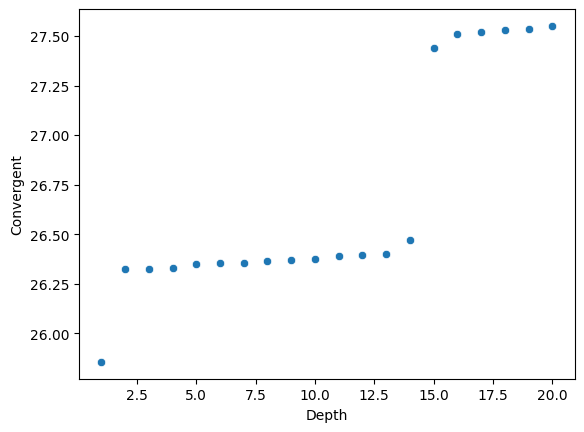

In [134]:
#Plot possible CoLog values over # of terms
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import random

def colog_vals_per_depth (depth):

  #start with depth 1:
  bin_vectors = np.array([[0], [1]])

  if (depth == 1):
    return [recurrence_formula([0], 'CoLogNet'), recurrence_formula([1], 'CoLogNet')]

  data = []

  for term in range(1, depth):
    #for each term, it can be 0 or 1
    a = 0.0
    b = 1.0

    column_a = np.full((bin_vectors.shape[0], 1), a)
    column_b = np.full((bin_vectors.shape[0], 1), b)

    updated_a = np.hstack((bin_vectors, column_a))
    updated_b = np.hstack((bin_vectors, column_b))

    bin_vectors = np.vstack((updated_a, updated_b))

  for row in bin_vectors:
    row = torch.Tensor(row)
    colog_val = recurrence_formula(row, 'CoLogNet')
    data.append(colog_val)

  return data

def plt_colog_vals (max_depth): #plot colog values over depth up to max depth
  data = []

  for depth in range(1, max_depth + 1): # [1, max_depth]
    colog_vals = colog_vals_per_depth(depth)
    colog_vals = np.array(colog_vals)

    depth_column = np.full((colog_vals.shape[0], 1), depth)

    curr_data = np.hstack((depth_column, colog_vals.reshape(-1, 1)))
    data.append(curr_data)

  data = np.vstack(data)
  df = pd.DataFrame(data)
  #print(df)
  df.columns = ['Depth', 'CoLog Value']
  sns.scatterplot(x='Depth', y='CoLog Value', data=df)

def plt_convergents (arr): #plot convergents over depth up to max depth
  data = []
  for depth in range(1, len(arr) + 1):
    partial = arr[0:depth]
    convergent = recurrence_formula(partial, 'CoFrNet')

    data.append([depth, convergent])
  df = np.vstack(data)
  df = pd.DataFrame(data)
  #print(df)
  df.columns = ['Depth', 'Convergent']
  sns.scatterplot(x = 'Depth', y = 'Convergent', data = df)


random_bin_list = [random.randint(0, 1) for _ in range(20)]
random_list = [random.uniform(0, 100) for _ in range(20)]

print(random_list)
plt_convergents(random_list)

#plt_colog_vals(8)


In [ ]:
#Hamming Model

class HammDist_Model(nn.Module):
  '''
  1) Binarizes inputs
  2) Takes hamming distance of inputs and weights
  3) Multiply by weights to get vector of length output_size
  '''

  def __init__(self):


  def forward(self, inputs)